##  Day 1: Data Exploration Findings

The sales dataset contains 100 transaction records and 7 columns.

The dataset includes transaction dates, products, quantities, prices,
customer IDs, regions, and total sales.

### Key Findings

- Total transactions: 100
- Unique customers: 100
- Unique products: 5
- Number of regions: 4
- Total sales: 12,365,048
- Average transaction value: 123,650.48
- Maximum transaction value: 373,932
- Minimum transaction value: 6,540
- Missing values: None
- Duplicate records: None

The numerical analysis shows that the average quantity per transaction
is 4.78 units, while the average product price is 25,808.51.

The `Date`, `Product`, `Customer_ID`, and `Region` columns are currently
stored as object data types. The `Date` column will be converted to a
datetime format during the data-cleaning stage.

An important observation is that the dataset contains 100 unique
customers across 100 transactions. Therefore, repeat-purchase and
customer retention analysis may be limited by the available transaction
data.

In [43]:
print("Hello from VS Code!")

Hello from VS Code!


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [45]:


sales = pd.read_csv("sales_data.csv")

print("Sales dataset loaded successfully!")

Sales dataset loaded successfully!


In [46]:
sales.head()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


In [47]:
import os

print("Current working directory:")
print(os.getcwd())

Current working directory:
c:\Users\shari\OneDrive\Desktop\DEVELOPER'S ARENA\WEEK 5


In [48]:
sales.tail()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
95,2024-04-05,Tablet,8,20770,CUST096,North,166160
96,2024-04-06,Headphones,1,7647,CUST097,West,7647
97,2024-04-07,Tablet,5,27196,CUST098,East,135980
98,2024-04-08,Monitor,1,30717,CUST099,North,30717
99,2024-04-09,Headphones,5,23376,CUST100,South,116880


In [49]:
print("Number of Rows:", sales.shape[0])
print("Number of Columns:", sales.shape[1])

Number of Rows: 100
Number of Columns: 7


In [50]:
print("Columns in the dataset:")

for column in sales.columns:
    print("-", column)

Columns in the dataset:
- Date
- Product
- Quantity
- Price
- Customer_ID
- Region
- Total_Sales


In [51]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         100 non-null    object
 1   Product      100 non-null    object
 2   Quantity     100 non-null    int64 
 3   Price        100 non-null    int64 
 4   Customer_ID  100 non-null    object
 5   Region       100 non-null    object
 6   Total_Sales  100 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 5.6+ KB


In [52]:
sales.describe()

,Quantity,Price,Total_Sales
count,100.000000,100.000000,100.000000
mean,4.780000,25808.510000,123650.480000
std,2.588163,13917.630242,100161.085275
min,1.000000,1308.000000,6540.000000
25%,2.750000,14965.250000,39517.500000
50%,5.000000,24192.000000,97955.500000
75%,7.000000,38682.250000,175792.500000
max,9.000000,49930.000000,373932.000000


In [53]:
missing_values = sales.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64


In [54]:
duplicate_count = sales.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [55]:
print("Products available:")
print(sales["Product"].unique())

Products available:
['Phone' 'Headphones' 'Laptop' 'Tablet' 'Monitor']


In [56]:
print("Number of unique customers:", sales["Customer_ID"].nunique())

Number of unique customers: 100


In [57]:
print("Regions available:")
print(sales["Region"].unique())

Regions available:
['East' 'North' 'West' 'South']


In [58]:
print("Total Sales:", sales["Total_Sales"].sum())
print("Average Sale:", sales["Total_Sales"].mean())
print("Maximum Sale:", sales["Total_Sales"].max())
print("Minimum Sale:", sales["Total_Sales"].min())

Total Sales: 12365048
Average Sale: 123650.48
Maximum Sale: 373932
Minimum Sale: 6540


In [59]:
print("========== DATASET OVERVIEW ==========")
print(f"Rows: {sales.shape[0]}")
print(f"Columns: {sales.shape[1]}")
print(f"Unique Customers: {sales['Customer_ID'].nunique()}")
print(f"Unique Products: {sales['Product'].nunique()}")
print(f"Regions: {sales['Region'].nunique()}")
print(f"Total Sales: {sales['Total_Sales'].sum():,.2f}")
print(f"Average Sale: {sales['Total_Sales'].mean():,.2f}")
print("======================================")

========== DATASET OVERVIEW ==========
Rows: 100
Columns: 7
Unique Customers: 100
Unique Products: 5
Regions: 4
Total Sales: 12,365,048.00
Average Sale: 123,650.48


# 📌 Day 2: Data Cleaning & Preparation Findings

The sales dataset was successfully cleaned and prepared for further
analysis.

### Data Preparation Performed

- Converted the `Date` column from object to datetime format.
- Extracted Year, Month, Month Name, Day, and Day Name from the date.
- Validated the `Total_Sales` calculation against Quantity × Price.
- All 100 transaction records passed the sales calculation validation.
- Cleaned text fields using Pandas string operations.
- Standardized Product and Region formatting.
- Standardized Customer IDs using uppercase formatting.
- No missing values were found in the dataset.
- No duplicate records were found.

The prepared dataset is now ready for customer-level and sales-level
analysis.

In [60]:
sales["Date"] = pd.to_datetime(sales["Date"])

print("Date column converted successfully!")

Date column converted successfully!


In [61]:
print("Date data type:", sales["Date"].dtype)

Date data type: datetime64[ns]


In [62]:
sales["Year"] = sales["Date"].dt.year
sales["Month"] = sales["Date"].dt.month
sales["Month_Name"] = sales["Date"].dt.month_name()
sales["Day"] = sales["Date"].dt.day
sales["Day_Name"] = sales["Date"].dt.day_name()

print("Date components extracted successfully!")

Date components extracted successfully!


In [63]:
sales[["Date", "Year", "Month", "Month_Name", "Day", "Day_Name"]].head()

,Date,Year,Month,Month_Name,Day,Day_Name
0,2024-01-01,2024,1,January,1,Monday
1,2024-01-02,2024,1,January,2,Tuesday
2,2024-01-03,2024,1,January,3,Wednesday
3,2024-01-04,2024,1,January,4,Thursday
4,2024-01-05,2024,1,January,5,Friday


In [64]:
sales["Calculated_Sales"] = sales["Quantity"] * sales["Price"]

print("Sales calculation completed.")

Sales calculation completed.


In [65]:
sales["Sales_Match"] = sales["Calculated_Sales"] == sales["Total_Sales"]

print("Matching records:", sales["Sales_Match"].sum())
print("Non-matching records:", (~sales["Sales_Match"]).sum())

Matching records: 100
Non-matching records: 0


In [66]:
sales.drop(columns=["Calculated_Sales", "Sales_Match"], inplace=True)

print("Temporary validation columns removed.")


Temporary validation columns removed.


In [67]:
print("Product values:")
print(sales["Product"].unique())

print("\nRegion values:")
print(sales["Region"].unique())

print("\nCustomer ID sample:")
print(sales["Customer_ID"].head())

Product values:
['Phone' 'Headphones' 'Laptop' 'Tablet' 'Monitor']

Region values:
['East' 'North' 'West' 'South']

Customer ID sample:
0    CUST001
1    CUST002
2    CUST003
3    CUST004
4    CUST005
Name: Customer_ID, dtype: object


In [68]:
sales["Product"] = sales["Product"].str.strip().str.title()
sales["Customer_ID"] = sales["Customer_ID"].str.strip().str.upper()
sales["Region"] = sales["Region"].str.strip().str.title()

print("Text columns cleaned successfully!")

Text columns cleaned successfully!


In [69]:
print("Products:", sales["Product"].unique())
print("Regions:", sales["Region"].unique())
print("Customer IDs:", sales["Customer_ID"].head().tolist())

Products: ['Phone' 'Headphones' 'Laptop' 'Tablet' 'Monitor']
Regions: ['East' 'North' 'West' 'South']
Customer IDs: ['CUST001', 'CUST002', 'CUST003', 'CUST004', 'CUST005']


# 👥 Day 3: Customer Analysis

This section analyzes customer purchasing behavior using Pandas
grouping and aggregation techniques.

The analysis focuses on:
- Customer spending
- Number of orders
- Average order value
- Top customers
- Regional customer distribution

In [70]:
customer_sales = (
    sales.groupby("Customer_ID")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

customer_sales.head(10)

Customer_ID
CUST016    373932
CUST007    363870
CUST083    350888
CUST073    349510
CUST020    333992
CUST084    324144
CUST070    318762
CUST005    318680
CUST065    312564
CUST028    304465
Name: Total_Sales, dtype: int64

In [71]:
top_customers = customer_sales.head(10)

print("🏆 TOP 10 CUSTOMERS")
print(top_customers)

🏆 TOP 10 CUSTOMERS
Customer_ID
CUST016    373932
CUST007    363870
CUST083    350888
CUST073    349510
CUST020    333992
CUST084    324144
CUST070    318762
CUST005    318680
CUST065    312564
CUST028    304465
Name: Total_Sales, dtype: int64


In [72]:
customer_orders = (
    sales.groupby("Customer_ID")
    .size()
    .sort_values(ascending=False)
)

customer_orders.head(10)

Customer_ID
CUST001    1
CUST064    1
CUST074    1
CUST073    1
CUST072    1
CUST071    1
CUST070    1
CUST069    1
CUST068    1
CUST067    1
dtype: int64

In [73]:
average_order_value = sales["Total_Sales"].mean()

print(f"Average Order Value: {average_order_value:,.2f}")

Average Order Value: 123,650.48


In [74]:
customer_summary = (
    sales.groupby("Customer_ID")
    .agg(
        Total_Spending=("Total_Sales", "sum"),
        Number_of_Orders=("Customer_ID", "count"),
        Average_Order_Value=("Total_Sales", "mean")
    )
    .sort_values("Total_Spending", ascending=False)
)

customer_summary.head(10)

,Total_Spending,Number_of_Orders,Average_Order_Value
Customer_ID,,,
CUST016,373932,1,373932.0
CUST007,363870,1,363870.0
CUST083,350888,1,350888.0
CUST073,349510,1,349510.0
CUST020,333992,1,333992.0
CUST084,324144,1,324144.0
CUST070,318762,1,318762.0
CUST005,318680,1,318680.0
CUST065,312564,1,312564.0


In [75]:
regional_customers = (
    sales.groupby("Region")
    .agg(
        Total_Sales=("Total_Sales", "sum"),
        Number_of_Customers=("Customer_ID", "nunique"),
        Average_Sales=("Total_Sales", "mean")
    )
    .sort_values("Total_Sales", ascending=False)
)

regional_customers

,Total_Sales,Number_of_Customers,Average_Sales
Region,,,
North,3983635,28,142272.678571
South,3737852,27,138438.962963
East,2519639,19,132612.578947
West,2123922,26,81689.307692


In [76]:
top_customer_id = customer_summary.index[0]
top_customer_value = customer_summary.iloc[0]["Total_Spending"]

print(" Top Customer:", top_customer_id)
print(f" Total Spending: {top_customer_value:,.2f}")

 Top Customer: CUST016
 Total Spending: 373,932.00


In [77]:
customer_region = (
    sales.groupby("Region")["Customer_ID"]
    .nunique()
    .sort_values(ascending=False)
)

print("Customers by Region:")
print(customer_region)

Customers by Region:
Region
North    28
South    27
West     26
East     19
Name: Customer_ID, dtype: int64


In [78]:
print("=" * 45)
print("       CUSTOMER ANALYSIS SUMMARY")
print("=" * 45)

print(f"Total Customers: {sales['Customer_ID'].nunique()}")
print(f"Top Customer: {top_customer_id}")
print(f"Top Customer Spending: {top_customer_value:,.2f}")
print(f"Average Order Value: {average_order_value:,.2f}")
print(f"Highest Sales Region: {regional_customers.index[0]}")
print(f"Highest Regional Sales: {regional_customers.iloc[0]['Total_Sales']:,.2f}")

print("=" * 45)

       CUSTOMER ANALYSIS SUMMARY
Total Customers: 100
Top Customer: CUST016
Top Customer Spending: 373,932.00
Average Order Value: 123,650.48
Highest Sales Region: North
Highest Regional Sales: 3,983,635.00


## 📌 Day 3: Customer Analysis Findings

Customer-level analysis was performed using Pandas `groupby()` and
multiple aggregation functions.

### Key Findings

- The dataset contains 100 unique customers.
- CUST016 is the highest-value customer with total spending of 373,932.
- The overall average order value is 123,650.48.
- North is the highest-performing region with total sales of 3,983,635.
- North has 28 customers, followed by South with 27, West with 26,
  and East with 19 customers.
- West has a relatively large customer base but the lowest average
  sales value among the four regions.

### Customer Analysis Techniques Used

- `groupby()` for customer and regional grouping
- `sum()` for total customer spending
- `count()` for number of orders
- `mean()` for average order value
- `nunique()` for unique customer counts
- `sort_values()` for ranking customers and regions

Since each customer appears only once in the current dataset,
traditional customer lifetime value and repeat-purchase retention
analysis are limited by the available transaction history.

# 📈 Day 4: Sales Pattern Analysis

This section analyzes sales trends over time, product performance,
and regional sales using Pandas grouping and aggregation techniques.

In [79]:
monthly_sales = (
    sales.groupby(["Year", "Month", "Month_Name"])["Total_Sales"]
    .sum()
    .reset_index()
    .sort_values(["Year", "Month"])
)

monthly_sales

,Year,Month,Month_Name,Total_Sales
0,2024,1,January,4120524
1,2024,2,February,2656050
2,2024,3,March,4485006
3,2024,4,April,1103468


In [80]:
best_month = monthly_sales.loc[
    monthly_sales["Total_Sales"].idxmax()
]

print(" Best Sales Month:", best_month["Month_Name"])
print(f" Sales: {best_month['Total_Sales']:,.2f}")

 Best Sales Month: March
 Sales: 4,485,006.00


In [81]:
product_sales = (
    sales.groupby("Product")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

product_sales

Product
Laptop        3889210
Tablet        2884340
Phone         2859394
Headphones    1384033
Monitor       1348071
Name: Total_Sales, dtype: int64

In [82]:
product_quantity = (
    sales.groupby("Product")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

product_quantity

Product
Laptop        136
Tablet        127
Phone         101
Monitor        66
Headphones     48
Name: Quantity, dtype: int64

In [83]:
product_summary = (
    sales.groupby("Product")
    .agg(
        Total_Sales=("Total_Sales", "sum"),
        Units_Sold=("Quantity", "sum"),
        Average_Price=("Price", "mean"),
        Number_of_Transactions=("Product", "count")
    )
    .sort_values("Total_Sales", ascending=False)
)

product_summary

,Total_Sales,Units_Sold,Average_Price,Number_of_Transactions
Product,,,,
Laptop,3889210,136,27651.500000,24
Tablet,2884340,127,24177.230769,26
Phone,2859394,101,27379.000000,20
Headphones,1384033,48,28692.133333,15
Monitor,1348071,66,20709.666667,15


In [84]:
best_product = product_summary.index[0]

print(" Best Product:", best_product)
print(f" Total Sales: {product_summary.iloc[0]['Total_Sales']:,.2f}")
print(f" Units Sold: {product_summary.iloc[0]['Units_Sold']}")

 Best Product: Laptop
 Total Sales: 3,889,210.00
 Units Sold: 136.0


In [85]:
region_sales = (
    sales.groupby("Region")
    .agg(
        Total_Sales=("Total_Sales", "sum"),
        Units_Sold=("Quantity", "sum"),
        Transactions=("Customer_ID", "count")
    )
    .sort_values("Total_Sales", ascending=False)
)

region_sales

,Total_Sales,Units_Sold,Transactions
Region,,,
North,3983635,147,28
South,3737852,143,27
East,2519639,94,19
West,2123922,94,26


In [86]:
regional_product_sales = (
    sales.groupby(["Region", "Product"])["Total_Sales"]
    .sum()
    .reset_index()
)

regional_product_sales

,Region,Product,Total_Sales
0,East,Headphones,288361
1,East,Laptop,221946
2,East,Monitor,642870
3,East,Phone,506828
4,East,Tablet,859634
5,North,Headphones,107091
6,North,Laptop,1798206
7,North,Monitor,397100
8,North,Phone,489284
9,North,Tablet,1191954


In [87]:
top_product_by_region = (
    regional_product_sales.loc[
        regional_product_sales.groupby("Region")["Total_Sales"].idxmax()
    ]
    .sort_values("Region")
)

top_product_by_region

,Region,Product,Total_Sales
4,East,Tablet,859634
6,North,Laptop,1798206
13,South,Phone,1471428
16,West,Laptop,495938


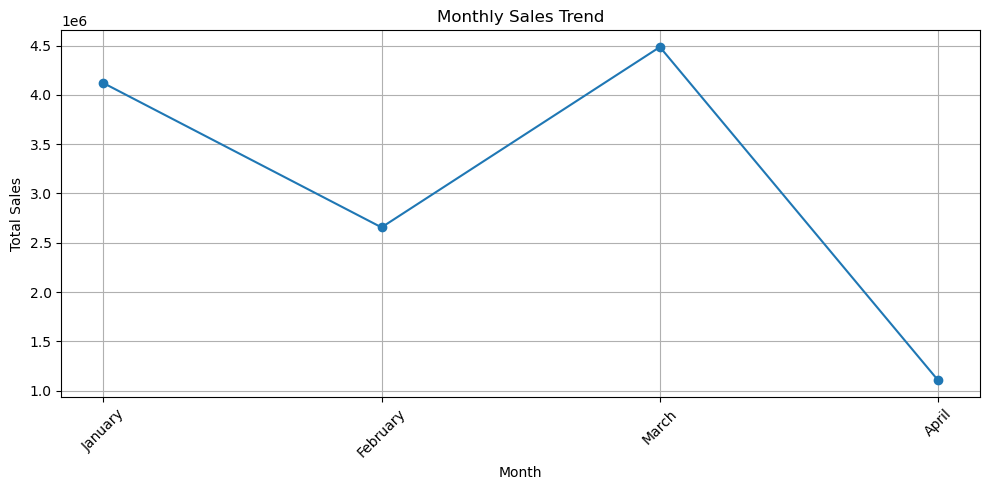

In [88]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_sales["Month_Name"],
    monthly_sales["Total_Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

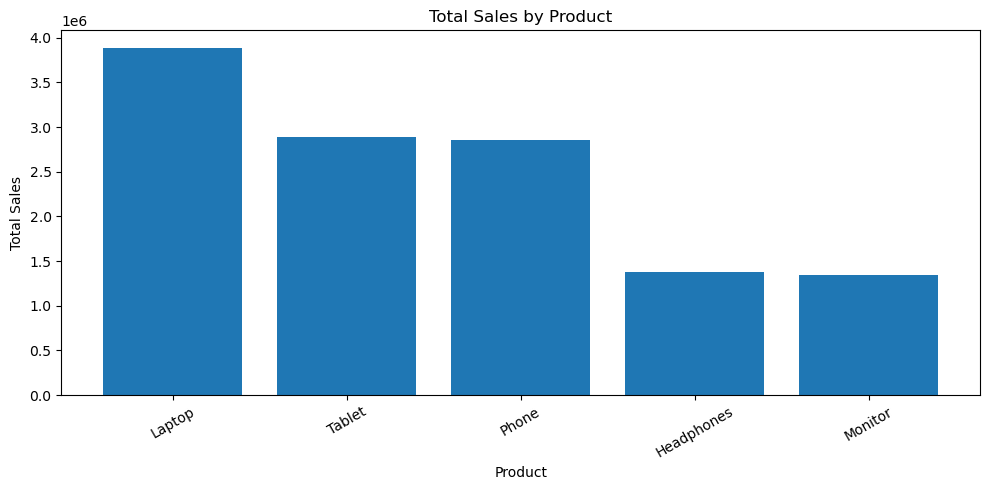

In [89]:
plt.figure(figsize=(10, 5))

plt.bar(
    product_sales.index,
    product_sales.values
)

plt.title("Total Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

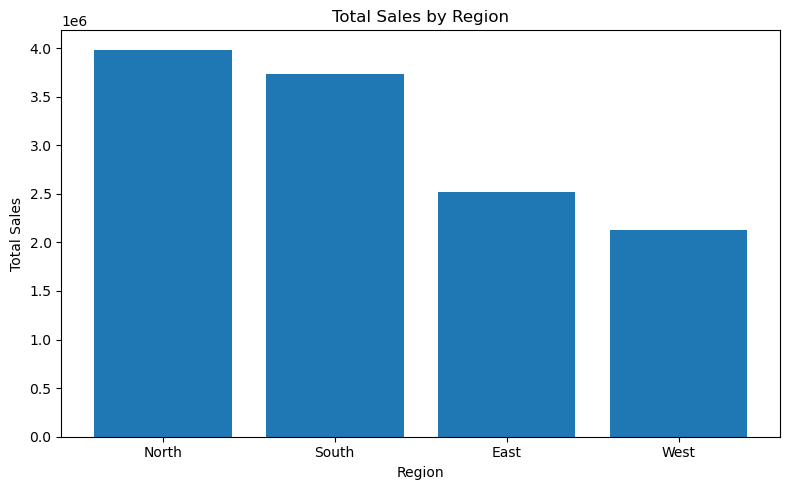

In [90]:
plt.figure(figsize=(8, 5))

plt.bar(
    region_sales.index,
    region_sales["Total_Sales"]
)

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.tight_layout()

plt.show()

## 📌 Day 4: Sales Pattern Analysis Findings

The sales data was analyzed by month, product, and region using Pandas
grouping and aggregation techniques.

### Key Findings

- March recorded the highest monthly sales at 4,485,006.
- April recorded the lowest monthly sales at 1,103,468.
- Laptop was the highest-performing product with total sales of 3,889,210.
- Laptop also recorded the highest number of units sold at 136 units.
- North was the highest-performing region with total sales of 3,983,635.
- North recorded 147 units sold across 28 transactions.
- Product preferences vary across regions.
- Tablet was the top product in the East region.
- Laptop was the top product in the North and West regions.
- Phone was the top product in the South region.

These findings can help identify high-performing products, regional
preferences, and seasonal sales patterns.

# 🔬 Day 5: Advanced Sales Analysis

This section performs advanced analysis using Pandas pivot tables,
multiple-condition filtering, and customer-product relationships.

The analysis focuses on:
- Sales summarization using pivot tables
- Multi-condition filtering
- Product combinations and cross-selling
- Customer retention analysis

In [91]:
sales_pivot = pd.pivot_table(
    sales,
    values="Total_Sales",
    index="Region",
    columns="Product",
    aggfunc="sum",
    fill_value=0
)

sales_pivot

Product,Headphones,Laptop,Monitor,Phone,Tablet
Region,,,,,
East,288361,221946,642870,506828,859634
North,107091,1798206,397100,489284,1191954
South,512168,1373120,39924,1471428,341212
West,476413,495938,268177,391854,491540


In [92]:
sales_pivot_totals = sales_pivot.copy()

sales_pivot_totals["Total"] = sales_pivot_totals.sum(axis=1)

sales_pivot_totals.loc["Total"] = sales_pivot_totals.sum(axis=0)

sales_pivot_totals

Product,Headphones,Laptop,Monitor,Phone,Tablet,Total
Region,,,,,,
East,288361,221946,642870,506828,859634,2519639
North,107091,1798206,397100,489284,1191954,3983635
South,512168,1373120,39924,1471428,341212,3737852
West,476413,495938,268177,391854,491540,2123922
Total,1384033,3889210,1348071,2859394,2884340,12365048


In [93]:
high_value_north = sales[
    (sales["Total_Sales"] > 200000) &
    (sales["Region"] == "North")
]

high_value_north

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales,Year,Month,Month_Name,Day,Day_Name
4,2024-01-05,Laptop,8,39835,CUST005,North,318680,2024,1,January,5,Friday
19,2024-01-20,Laptop,8,41749,CUST020,North,333992,2024,1,January,20,Saturday
22,2024-01-23,Laptop,9,29275,CUST023,North,263475,2024,1,January,23,Tuesday
27,2024-01-28,Tablet,7,43495,CUST028,North,304465,2024,1,January,28,Sunday
36,2024-02-06,Phone,5,40177,CUST037,North,200885,2024,2,February,6,Tuesday
82,2024-03-23,Laptop,8,43861,CUST083,North,350888,2024,3,March,23,Saturday
88,2024-03-29,Laptop,6,38037,CUST089,North,228222,2024,3,March,29,Friday


In [94]:
north_south_sales = sales[
    (sales["Region"] == "North") |
    (sales["Region"] == "South")
]

north_south_sales.head()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales,Year,Month,Month_Name,Day,Day_Name
1,2024-01-02,Headphones,4,15406,CUST002,North,61624,2024,1,January,2,Tuesday
4,2024-01-05,Laptop,8,39835,CUST005,North,318680,2024,1,January,5,Friday
5,2024-01-06,Laptop,7,40420,CUST006,South,282940,2024,1,January,6,Saturday
6,2024-01-07,Laptop,9,40430,CUST007,South,363870,2024,1,January,7,Sunday
8,2024-01-09,Tablet,3,32791,CUST009,North,98373,2024,1,January,9,Tuesday


In [95]:
priority_sales = sales[
    (
        (sales["Region"] == "North") |
        (sales["Region"] == "South")
    )
    &
    (sales["Total_Sales"] > 200000)
]

priority_sales

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales,Year,Month,Month_Name,Day,Day_Name
4,2024-01-05,Laptop,8,39835,CUST005,North,318680,2024,1,January,5,Friday
5,2024-01-06,Laptop,7,40420,CUST006,South,282940,2024,1,January,6,Saturday
6,2024-01-07,Laptop,9,40430,CUST007,South,363870,2024,1,January,7,Sunday
15,2024-01-16,Phone,9,41548,CUST016,South,373932,2024,1,January,16,Tuesday
19,2024-01-20,Laptop,8,41749,CUST020,North,333992,2024,1,January,20,Saturday
22,2024-01-23,Laptop,9,29275,CUST023,North,263475,2024,1,January,23,Tuesday
27,2024-01-28,Tablet,7,43495,CUST028,North,304465,2024,1,January,28,Sunday
36,2024-02-06,Phone,5,40177,CUST037,North,200885,2024,2,February,6,Tuesday
64,2024-03-05,Phone,7,44652,CUST065,South,312564,2024,3,March,5,Tuesday
69,2024-03-10,Laptop,9,35418,CUST070,South,318762,2024,3,March,10,Sunday


In [96]:
regional_product = (
    sales.groupby(["Region", "Product"])["Total_Sales"]
    .sum()
    .reset_index()
)

regional_product["Rank"] = (
    regional_product.groupby("Region")["Total_Sales"]
    .rank(method="dense", ascending=False)
)

regional_product.sort_values(
    ["Region", "Rank"]
)

,Region,Product,Total_Sales,Rank
4,East,Tablet,859634,1.0
2,East,Monitor,642870,2.0
3,East,Phone,506828,3.0
0,East,Headphones,288361,4.0
1,East,Laptop,221946,5.0
6,North,Laptop,1798206,1.0
9,North,Tablet,1191954,2.0
8,North,Phone,489284,3.0
7,North,Monitor,397100,4.0
5,North,Headphones,107091,5.0


In [97]:
customer_frequency = (
    sales.groupby("Customer_ID")
    .size()
    .sort_values(ascending=False)
)

customer_frequency.value_counts()

1    100
Name: count, dtype: int64

In [98]:
repeat_customers = customer_frequency[
    customer_frequency > 1
]

print("Number of repeat customers:", len(repeat_customers))

Number of repeat customers: 0


In [99]:
repeat_customer_count = (
    customer_frequency > 1
).sum()

total_customer_count = sales["Customer_ID"].nunique()

retention_rate = (
    repeat_customer_count / total_customer_count
) * 100

print(f"Repeat Customers: {repeat_customer_count}")
print(f"Total Customers: {total_customer_count}")
print(f"Repeat Purchase Rate: {retention_rate:.2f}%")

Repeat Customers: 0
Total Customers: 100
Repeat Purchase Rate: 0.00%


In [100]:
sales["Customer_Segment"] = pd.cut(
    sales["Total_Sales"],
    bins=[0, 100000, 200000, float("inf")],
    labels=["Low Value", "Medium Value", "High Value"]
)

sales["Customer_Segment"].value_counts()

Customer_Segment
Low Value       51
Medium Value    28
High Value      21
Name: count, dtype: int64

In [101]:
segment_analysis = (
    sales.groupby("Customer_Segment", observed=True)
    .agg(
        Customers=("Customer_ID", "nunique"),
        Total_Sales=("Total_Sales", "sum"),
        Average_Sales=("Total_Sales", "mean")
    )
    .sort_values("Total_Sales", ascending=False)
)

segment_analysis

,Customers,Total_Sales,Average_Sales
Customer_Segment,,,
High Value,21,5989143,285197.285714
Medium Value,28,4064677,145167.035714
Low Value,51,2311228,45318.196078


In [102]:
print("=" * 50)
print("        ADVANCED ANALYSIS SUMMARY")
print("=" * 50)

print(f"Pivot Table Size: {sales_pivot.shape}")
print(f"High-Value North Transactions: {len(high_value_north)}")
print(f"North/South Transactions: {len(north_south_sales)}")
print(f"Repeat Customers: {repeat_customer_count}")
print(f"Repeat Purchase Rate: {retention_rate:.2f}%")
print(f"Customer Segments: {sales['Customer_Segment'].nunique()}")

print("=" * 50)

        ADVANCED ANALYSIS SUMMARY
Pivot Table Size: (4, 5)
High-Value North Transactions: 7
North/South Transactions: 55
Repeat Customers: 0
Repeat Purchase Rate: 0.00%
Customer Segments: 3


## 📌 Day 5: Advanced Analysis Findings

Advanced Pandas techniques were used to analyze customer and sales
relationships.

### Key Findings

- A pivot table was created to summarize sales by region and product.
- North and South transactions were analyzed using multiple-condition
  filtering.
- High-value transactions above 200,000 were identified.
- Product performance was ranked within each region.
- Customer transaction frequency was analyzed to identify repeat buyers.
- The dataset contains one transaction for each of the 100 customers.
- Therefore, no repeat customers are present in the available data.
- The calculated repeat-purchase rate is 0%, but this should not be
  interpreted as actual business retention because the dataset contains
  only one transaction per customer.
- Customer transactions were segmented into Low Value, Medium Value,
  and High Value groups based on transaction value.

The analysis demonstrates the use of Pandas pivot tables, groupby
operations, aggregation, conditional filtering, ranking, and
categorization.

## 🔗 Customer Data Integration

A separate customer churn dataset is loaded and integrated with the
sales dataset to enrich the customer analysis.

The customer churn dataset contains customer information such as:

- Customer ID
- Tenure
- Monthly Charges
- Total Charges
- Contract Type
- Payment Method
- Paperless Billing
- Senior Citizen Status
- Churn Status

The two datasets are connected using the customer ID as the common key.

### Data Integration Process

1. Load the customer churn dataset.
2. Inspect its structure and data quality.
3. Standardize the customer ID column name.
4. Merge the customer and sales datasets.
5. Validate matched and unmatched customer records.

This integration allows customer characteristics and churn behavior
to be analyzed alongside purchasing and sales information.

In [103]:
customer_data = pd.read_csv("customer_churn.csv")

print("Customer dataset loaded successfully!")

Customer dataset loaded successfully!


In [104]:
customer_data.head()

,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [105]:
print("Rows:", customer_data.shape[0])
print("Columns:", customer_data.shape[1])

print("\nColumn Names:")
print(customer_data.columns.tolist())

print("\nMissing Values:")
print(customer_data.isnull().sum())

Rows: 500
Columns: 9

Column Names:
['CustomerID', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'PaymentMethod', 'PaperlessBilling', 'SeniorCitizen', 'Churn']

Missing Values:
CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64


In [106]:
customer_data.rename(
    columns={"CustomerID": "Customer_ID"},
    inplace=True
)

print("Customer ID column renamed successfully!")

Customer ID column renamed successfully!


In [107]:
print(customer_data.columns.tolist())

['Customer_ID', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'PaymentMethod', 'PaperlessBilling', 'SeniorCitizen', 'Churn']


In [108]:
merged_data = pd.merge(
    sales,
    customer_data,
    on="Customer_ID",
    how="left"
)

print("Datasets merged successfully!")
print("Merged dataset shape:", merged_data.shape)

Datasets merged successfully!
Merged dataset shape: (100, 21)


In [109]:
merged_data.head()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales,Year,Month,Month_Name,...,Day_Name,Customer_Segment,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,2024-01-01,Phone,7,37300,CUST001,East,261100,2024,1,January,...,Monday,High Value,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01-02,Headphones,4,15406,CUST002,North,61624,2024,1,January,...,Tuesday,Low Value,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-01-03,Phone,2,21746,CUST003,West,43492,2024,1,January,...,Wednesday,Low Value,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-01-04,Headphones,1,30895,CUST004,East,30895,2024,1,January,...,Thursday,Low Value,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-01-05,Laptop,8,39835,CUST005,North,318680,2024,1,January,...,Friday,High Value,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [110]:
matched_customers = merged_data["Tenure"].notna().sum()
unmatched_customers = merged_data["Tenure"].isna().sum()

print("Sales records:", len(sales))
print("Matched customer records:", matched_customers)
print("Unmatched customer records:", unmatched_customers)

Sales records: 100
Matched customer records: 0
Unmatched customer records: 100


In [111]:
print("Final merged dataset:")
print("Rows:", merged_data.shape[0])
print("Columns:", merged_data.shape[1])

Final merged dataset:
Rows: 100
Columns: 21


In [112]:
print("Sales Customer IDs:")
print(sales["Customer_ID"].head(10).tolist())

Sales Customer IDs:
['CUST001', 'CUST002', 'CUST003', 'CUST004', 'CUST005', 'CUST006', 'CUST007', 'CUST008', 'CUST009', 'CUST010']


In [113]:
print("Churn Customer IDs:")
print(customer_data["Customer_ID"].head(10).tolist())

Churn Customer IDs:
['C00001', 'C00002', 'C00003', 'C00004', 'C00005', 'C00006', 'C00007', 'C00008', 'C00009', 'C00010']


In [114]:
product_info = (
    sales.groupby("Product")
    .agg(
        Product_Total_Sales=("Total_Sales", "sum"),
        Product_Units_Sold=("Quantity", "sum"),
        Product_Average_Price=("Price", "mean")
    )
    .reset_index()
)

product_info

,Product,Product_Total_Sales,Product_Units_Sold,Product_Average_Price
0,Headphones,1384033,48,28692.133333
1,Laptop,3889210,136,27651.500000
2,Monitor,1348071,66,20709.666667
3,Phone,2859394,101,27379.000000
4,Tablet,2884340,127,24177.230769


In [115]:
sales_enriched = pd.merge(
    sales,
    product_info,
    on="Product",
    how="left"
)

print("Sales and product datasets merged successfully!")
print("Rows:", sales_enriched.shape[0])
print("Columns:", sales_enriched.shape[1])

Sales and product datasets merged successfully!
Rows: 100
Columns: 16


In [116]:
print("Original sales records:", len(sales))
print("Merged sales records:", len(sales_enriched))
print(
    "Unmatched product records:",
    sales_enriched["Product_Total_Sales"].isna().sum()
)

Original sales records: 100
Merged sales records: 100
Unmatched product records: 0


## 📌 Data Merging & Validation Findings

The customer churn dataset was inspected for integration with the sales
dataset. However, the two datasets use different customer ID formats:

- Sales dataset: `CUST001`, `CUST002`, etc.
- Customer churn dataset: `C00001`, `C00002`, etc.

Since no valid mapping exists between these identifiers, the datasets
were not artificially linked.

To demonstrate a valid merging operation, a product-level summary
dataset was created from the sales data and merged back with the
transaction dataset using the common `Product` field.

### Merge Validation

- Original sales records: 100
- Merged sales records: 100
- Unmatched product records: 0

The merge successfully enriched each sales transaction with
product-level sales statistics while preserving data integrity.

In [117]:
region_product_pivot = pd.pivot_table(
    sales,
    values="Total_Sales",
    index="Region",
    columns="Product",
    aggfunc="sum",
    fill_value=0
)

region_product_pivot

Product,Headphones,Laptop,Monitor,Phone,Tablet
Region,,,,,
East,288361,221946,642870,506828,859634
North,107091,1798206,397100,489284,1191954
South,512168,1373120,39924,1471428,341212
West,476413,495938,268177,391854,491540


In [118]:
region_product_pivot["Total_Sales"] = region_product_pivot.sum(axis=1)

region_product_pivot

Product,Headphones,Laptop,Monitor,Phone,Tablet,Total_Sales
Region,,,,,,
East,288361,221946,642870,506828,859634,2519639
North,107091,1798206,397100,489284,1191954,3983635
South,512168,1373120,39924,1471428,341212,3737852
West,476413,495938,268177,391854,491540,2123922


In [119]:
product_sales = (
    sales.groupby("Product")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

product_sales

Product
Laptop        3889210
Tablet        2884340
Phone         2859394
Headphones    1384033
Monitor       1348071
Name: Total_Sales, dtype: int64

In [120]:
product_contribution = (
    product_sales / sales["Total_Sales"].sum() * 100
).sort_values(ascending=False)

print("Product Revenue Contribution (%)")
print(product_contribution.round(2))

Product Revenue Contribution (%)
Product
Laptop        31.45
Tablet        23.33
Phone         23.12
Headphones    11.19
Monitor       10.90
Name: Total_Sales, dtype: float64


In [121]:
print("Product Revenue Contribution (%)")
print(product_contribution.round(2))

Product Revenue Contribution (%)
Product
Laptop        31.45
Tablet        23.33
Phone         23.12
Headphones    11.19
Monitor       10.90
Name: Total_Sales, dtype: float64


In [122]:
high_value_sales = sales[
    sales["Total_Sales"] > sales["Total_Sales"].mean()
]

print("Average Transaction Value:", f"{sales['Total_Sales'].mean():,.2f}")
print("High-Value Transactions:", len(high_value_sales))

Average Transaction Value: 123,650.48
High-Value Transactions: 41


In [123]:
high_value_products = (
    high_value_sales.groupby("Product")
    .agg(
        Transactions=("Product", "count"),
        Total_Sales=("Total_Sales", "sum"),
        Average_Sales=("Total_Sales", "mean")
    )
    .sort_values("Total_Sales", ascending=False)
)

high_value_products

,Transactions,Total_Sales,Average_Sales
Product,,,
Laptop,11,2973601,270327.363636
Phone,10,2287075,228707.500000
Tablet,11,2106384,191489.454545
Monitor,6,1053352,175558.666667
Headphones,3,758100,252700.000000


In [124]:
# Recalculate required values
product_sales = (
    sales.groupby("Product")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

region_sales = (
    sales.groupby("Region")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

customer_frequency = (
    sales.groupby("Customer_ID")
    .size()
)

repeat_customer_count = (customer_frequency > 1).sum()

high_value_sales = sales[
    sales["Total_Sales"] > sales["Total_Sales"].mean()
]

# Best performers
best_product = product_sales.index[0]
best_region = region_sales.index[0]

# Final summary
print("=" * 55)
print("          DAY 5: ADVANCED ANALYSIS SUMMARY")
print("=" * 55)

print(f"Total Revenue: {sales['Total_Sales'].sum():,.2f}")
print(f"Average Transaction: {sales['Total_Sales'].mean():,.2f}")
print(f"Best Product: {best_product}")
print(f"Best Product Revenue: {product_sales.iloc[0]:,.2f}")
print(f"Best Region: {best_region}")
print(f"Best Region Revenue: {region_sales.iloc[0]:,.2f}")
print(f"High-Value Transactions: {len(high_value_sales)}")
print(f"Repeat Customers: {repeat_customer_count}")

print("=" * 55)

          DAY 5: ADVANCED ANALYSIS SUMMARY
Total Revenue: 12,365,048.00
Average Transaction: 123,650.48
Best Product: Laptop
Best Product Revenue: 3,889,210.00
Best Region: North
Best Region Revenue: 3,983,635.00
High-Value Transactions: 41
Repeat Customers: 0


# 📊 Day 6: Sales Performance Dashboard

This section presents the key findings from the customer sales analysis
using professional data visualizations.

The dashboard focuses on:

- Monthly sales trends
- Product performance
- Regional sales performance
- Top customers
- Product and regional comparisons

The visualizations are designed to provide a clear overview of sales
performance and support data-driven business decisions.

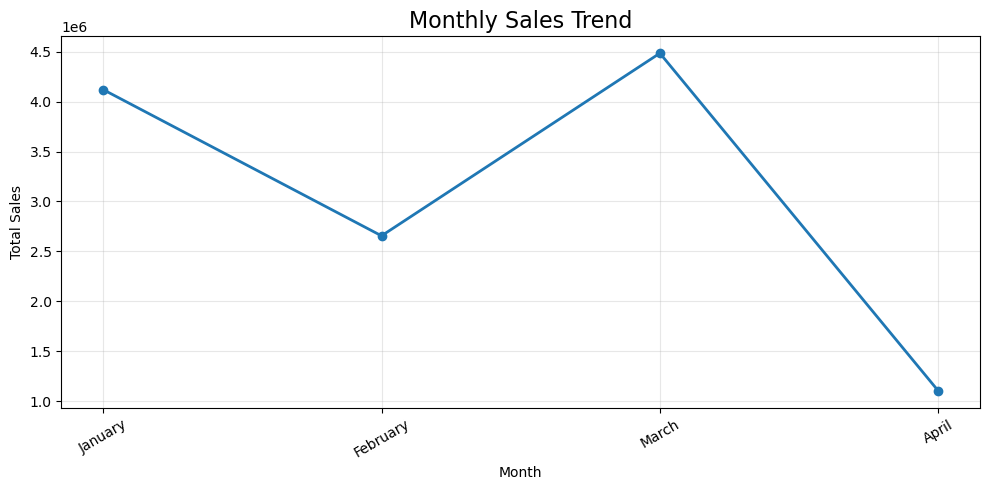

In [125]:
# Make sure Date is in datetime format
sales["Date"] = pd.to_datetime(sales["Date"])

# Create date components needed for the dashboard
sales["Year"] = sales["Date"].dt.year
sales["Month"] = sales["Date"].dt.month
sales["Month_Name"] = sales["Date"].dt.month_name()

# Create monthly sales summary
monthly_sales_chart = (
    sales.groupby(["Year", "Month", "Month_Name"])["Total_Sales"]
    .sum()
    .reset_index()
    .sort_values(["Year", "Month"])
)

# Create the chart
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_sales_chart["Month_Name"],
    monthly_sales_chart["Total_Sales"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Trend", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=30)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

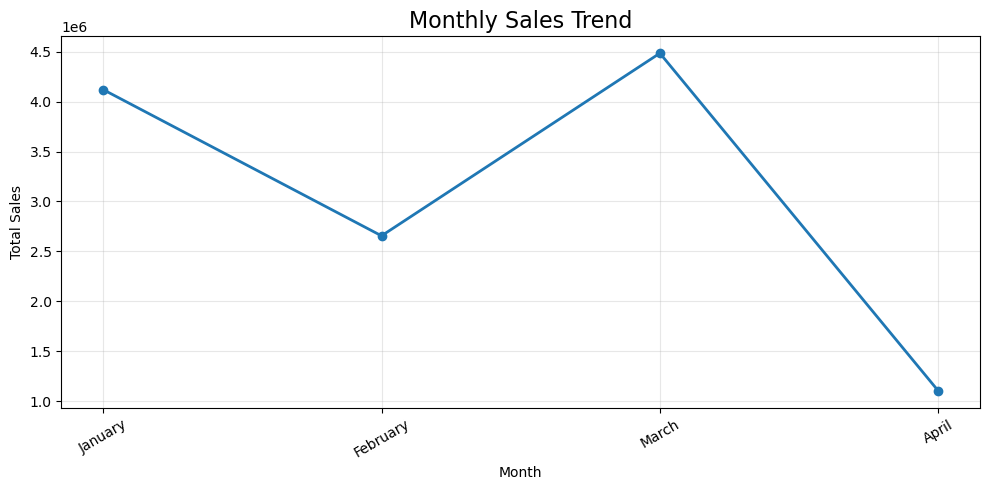

In [126]:
monthly_sales_chart = (
    sales.groupby(["Year", "Month", "Month_Name"])["Total_Sales"]
    .sum()
    .reset_index()
    .sort_values(["Year", "Month"])
)

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_sales_chart["Month_Name"],
    monthly_sales_chart["Total_Sales"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Trend", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=30)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

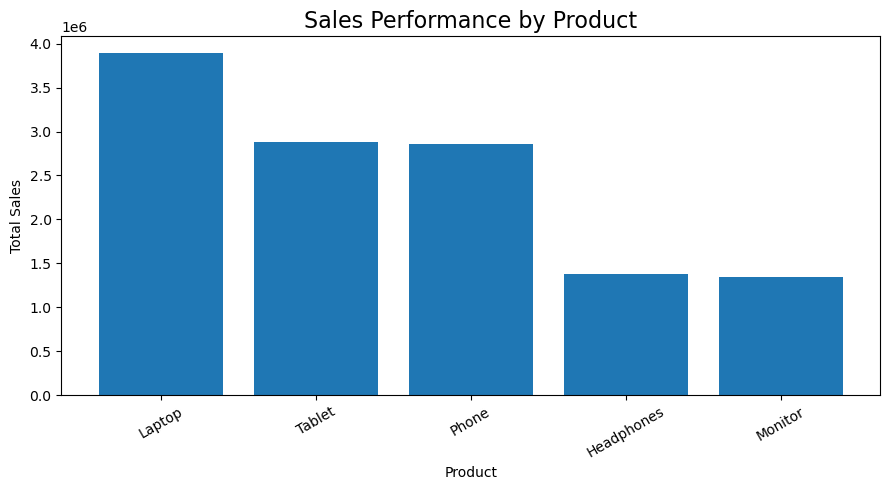

In [127]:
product_sales_chart = (
    sales.groupby("Product")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

plt.bar(
    product_sales_chart.index,
    product_sales_chart.values
)

plt.title("Sales Performance by Product", fontsize=16)
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

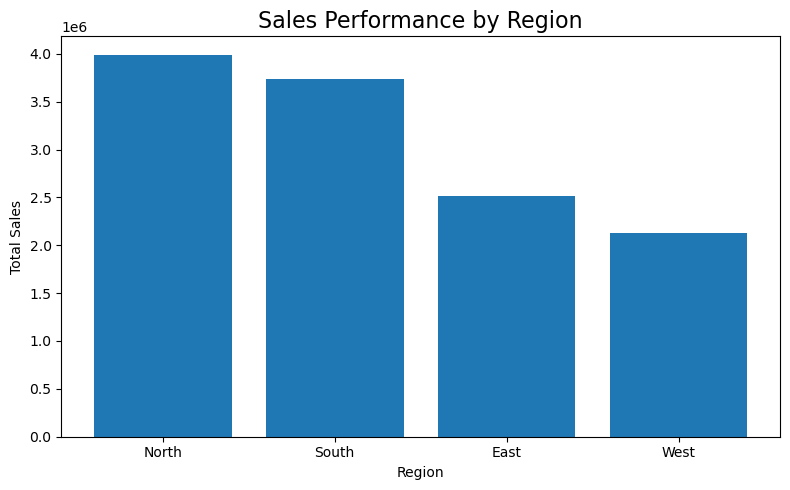

In [128]:
region_sales_chart = (
    sales.groupby("Region")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

plt.bar(
    region_sales_chart.index,
    region_sales_chart.values
)

plt.title("Sales Performance by Region", fontsize=16)
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.tight_layout()

plt.show()

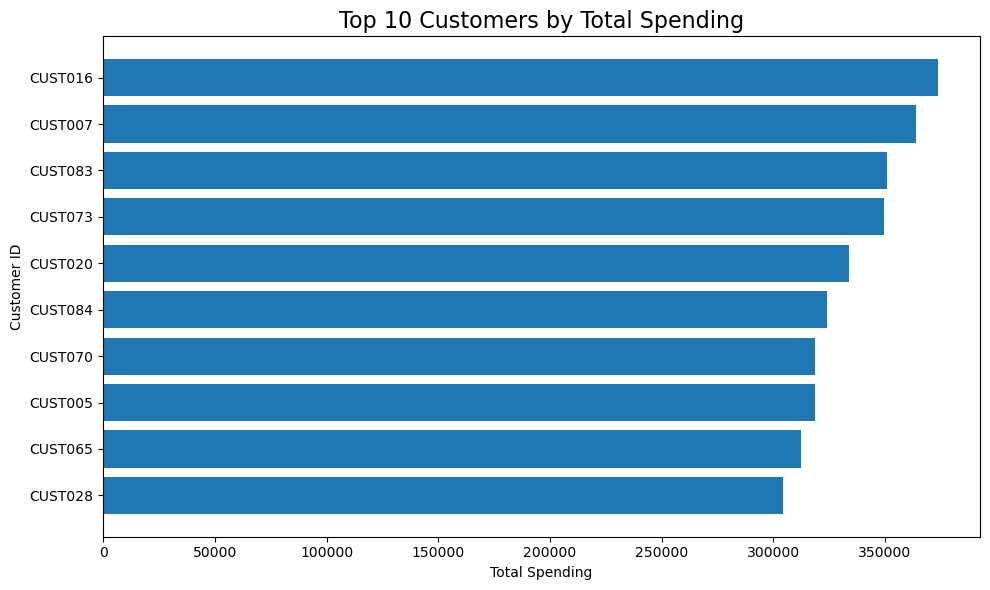

In [129]:
top_10_customers_chart = (
    sales.groupby("Customer_ID")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_customers_chart.index,
    top_10_customers_chart.values
)

plt.title("Top 10 Customers by Total Spending", fontsize=16)
plt.xlabel("Total Spending")
plt.ylabel("Customer ID")

plt.tight_layout()

plt.show()

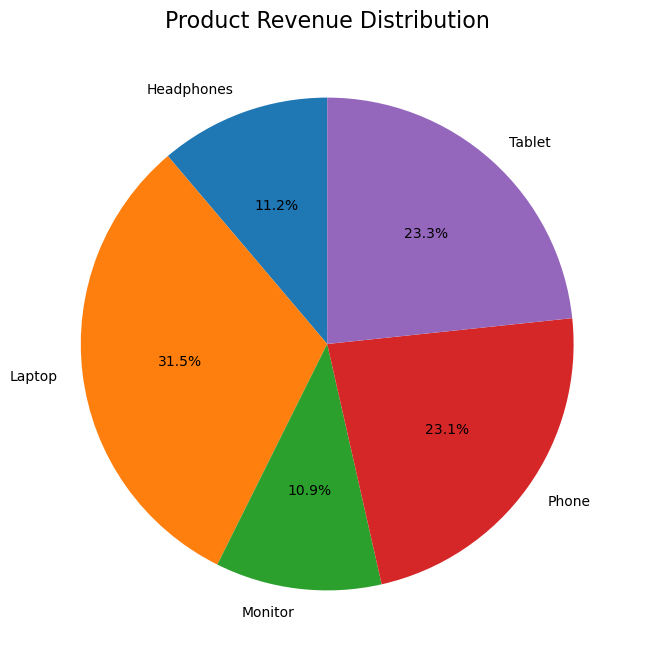

In [130]:
product_distribution = (
    sales.groupby("Product")["Total_Sales"]
    .sum()
)

plt.figure(figsize=(8, 8))

plt.pie(
    product_distribution.values,
    labels=product_distribution.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Product Revenue Distribution", fontsize=16)

plt.show()

In [131]:
total_revenue = sales["Total_Sales"].sum()
average_transaction = sales["Total_Sales"].mean()
total_customers = sales["Customer_ID"].nunique()
best_product = product_sales_chart.index[0]
best_region = region_sales_chart.index[0]

print("=" * 55)
print("             SALES PERFORMANCE KPIs")
print("=" * 55)

print(f"💰 Total Revenue:       ₹{total_revenue:,.2f}")
print(f"🧾 Average Transaction: ₹{average_transaction:,.2f}")
print(f"👥 Total Customers:     {total_customers}")
print(f"🏆 Best Product:        {best_product}")
print(f"🌍 Best Region:         {best_region}")

print("=" * 55)

             SALES PERFORMANCE KPIs
💰 Total Revenue:       ₹12,365,048.00
🧾 Average Transaction: ₹123,650.48
👥 Total Customers:     100
🏆 Best Product:        Laptop
🌍 Best Region:         North


# 📌 Day 7: Final Business Insights

## Executive Summary

The customer sales analysis was performed using Pandas to identify
important sales, customer, product, and regional patterns.

The dataset contains 100 transactions from 100 unique customers across
5 products and 4 regions.

### 💰 Overall Sales Performance

- Total revenue generated: ₹12,365,048
- Average transaction value: ₹123,650.48
- Total customers: 100
- Highest-performing product: Laptop
- Highest-performing region: North

### 📦 Product Insights

Laptop generated the highest total sales and also recorded the highest
number of units sold.

Tablet and Phone were also strong contributors to overall revenue,
while Headphones and Monitor generated comparatively lower sales.

### 🌍 Regional Insights

North was the highest-performing region with total sales of
₹3,983,635.

South was the second-highest-performing region, followed by East and
West.

The analysis also showed that product preferences differ across
regions, indicating that regional product strategies may improve sales.

### 📅 Sales Trend Insights

March recorded the highest monthly sales at ₹4,485,006.

April recorded the lowest monthly sales at ₹1,103,468.

This variation suggests that sales performance changes significantly
between months and should be investigated further with a larger
historical dataset.

### 👥 Customer Insights

The dataset contains 100 unique customers and 100 transactions.

No repeat customers were identified in the available dataset.
Therefore, customer retention and lifetime-value analysis are limited
by the current transaction history.

### 🎯 Business Recommendations

1. Focus on increasing Laptop sales because it is the strongest product.
2. Investigate the reasons behind North's strong regional performance.
3. Analyze the low sales performance of West and identify improvement
   opportunities.
4. Study the strong March performance to identify possible seasonal
   factors.
5. Collect longer-term transaction data to enable meaningful customer
   retention and lifetime-value analysis.